## Marketing Mix Modeling Analysis

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the data from the 'PyQ2' tab
file_path = 'Python Questions_IME interview Round.xlsx'
df = pd.read_excel(file_path, sheet_name='PyQ2', engine='openpyxl')
df = df.loc[:, ~df.columns.str.contains('Unnamed: 20|Unnamed: 21')]

# Preserve the 'Week_Ending' column for time series analysis
df['Week_Ending'] = pd.to_datetime(df['Week_Ending'])

# Remove non-numeric columns except 'Week_Ending'
numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.append('Week_Ending')
df = df[numeric_columns]

# Display the first few rows of the dataframe
df.head()

,Sales,Discount1,Discount2,Holiday Dummy,Total SKU,Gasoline Price,Average Price,Email Clicks,Email Spends,Organic Search Impressions,Modular Video Impressions,Modular Video Spends,Paid Social Impressions,Paid Social Spends,Paid Search Impressions,Paid Search Spends,Week_Ending
0,5.549708e+07,0.039253,0.015600,0,29882443.5,1070.8565,17.716258,534418.5,46008.276537,2662747.5,11599332.5,815220.956832,280464068.5,3.861346e+06,6779.5,671.943906,2022-02-05
1,5.773779e+07,0.037425,0.014623,0,29719511.5,1070.8565,17.720041,631368.5,54354.736119,2609978.0,13142160.5,923653.551413,235058652.5,3.236218e+06,5110.0,506.472949,2022-02-12
2,5.404445e+07,0.061313,0.010034,0,29353173.5,1070.8565,17.774548,638092.0,54933.564597,2401283.5,12949660.5,910124.321676,257480818.0,3.544920e+06,2842.0,281.682216,2022-02-19
3,5.577581e+07,0.066293,0.023455,0,29324354.5,1070.8565,17.771519,538643.0,46371.965227,2396597.0,12401567.5,871603.406796,276892035.0,3.812168e+06,3031.0,300.414777,2022-02-26
4,5.839206e+07,0.047306,0.015688,0,29192688.0,1282.7465,17.842527,639628.5,55065.842423,2427106.5,8857677.5,622532.747195,193081850.5,2.658294e+06,3395.0,336.492302,2022-03-05


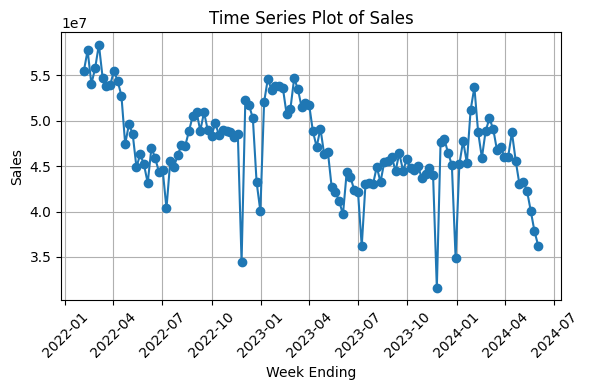

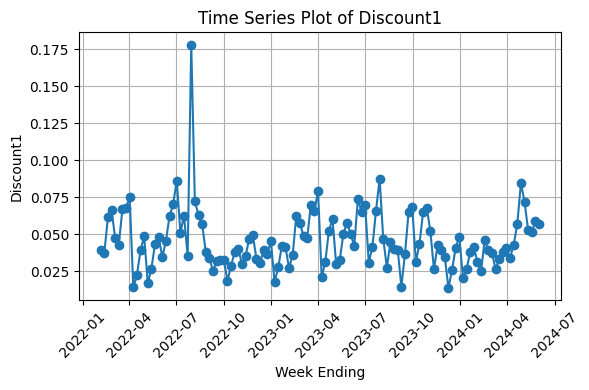

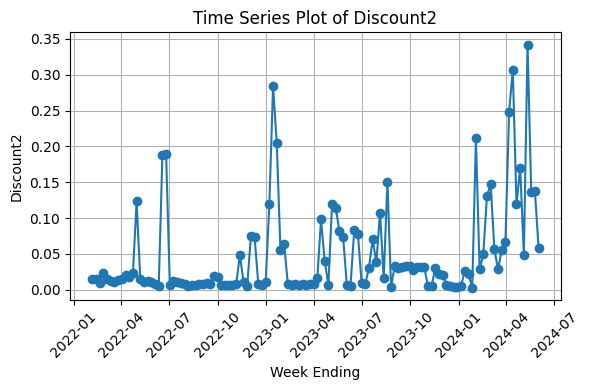

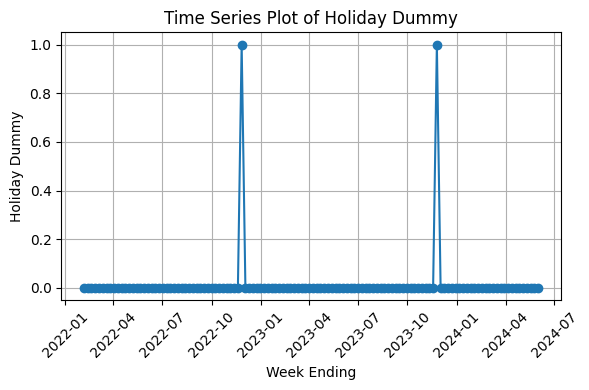

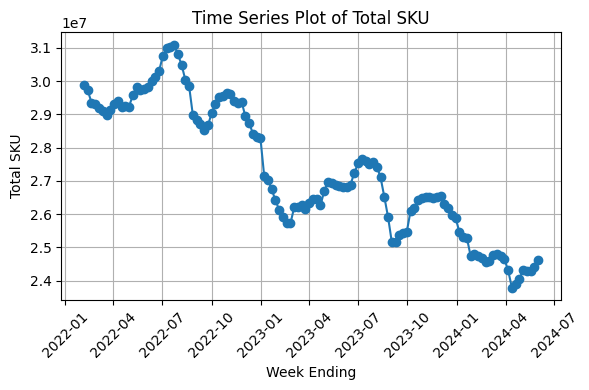

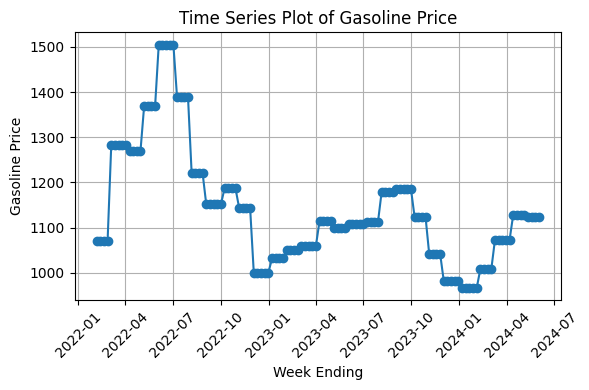

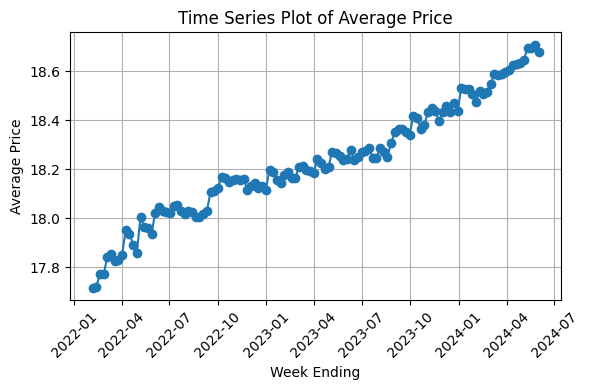

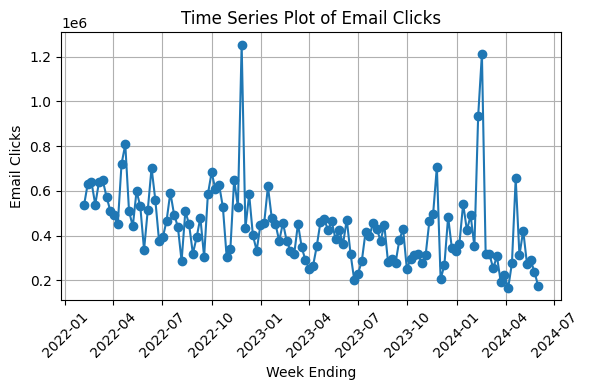

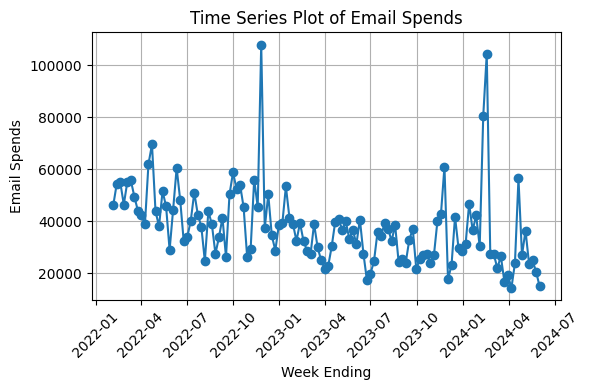

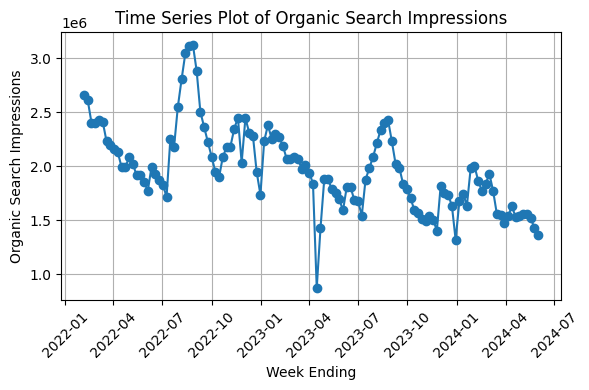

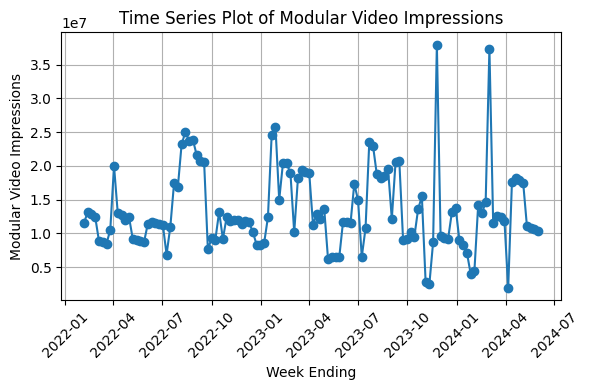

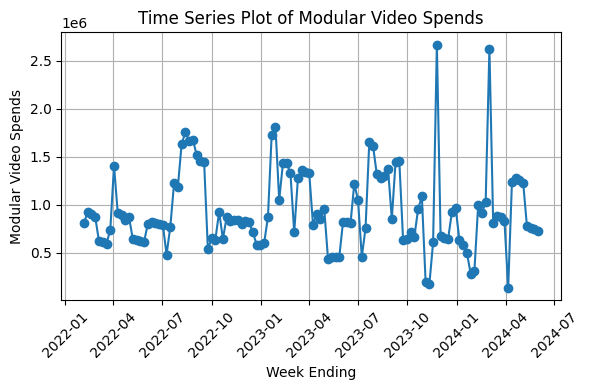

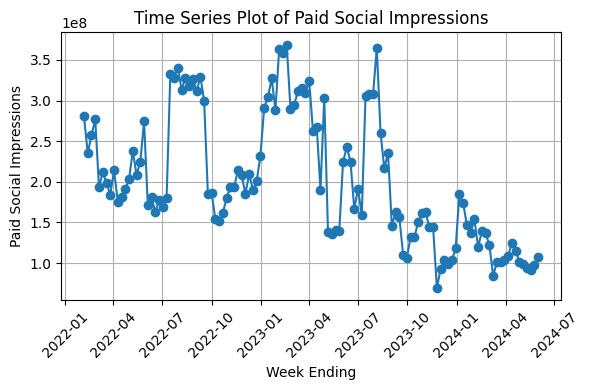

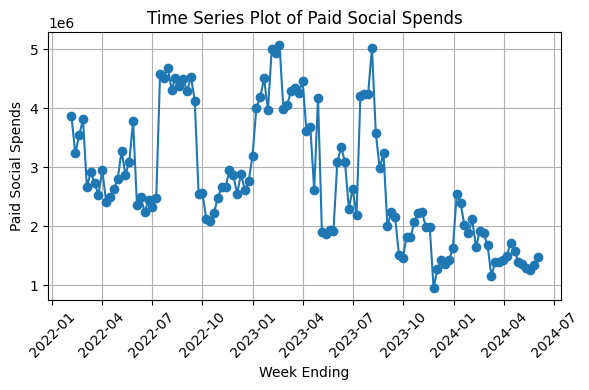

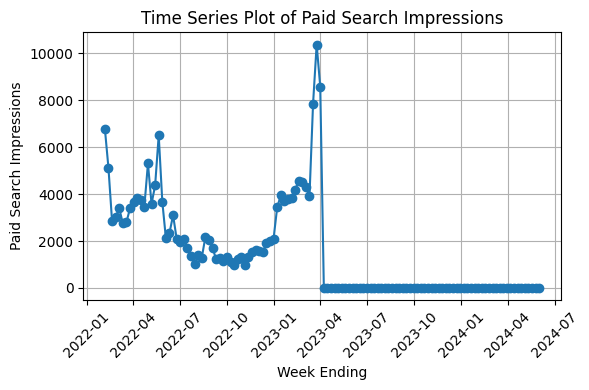

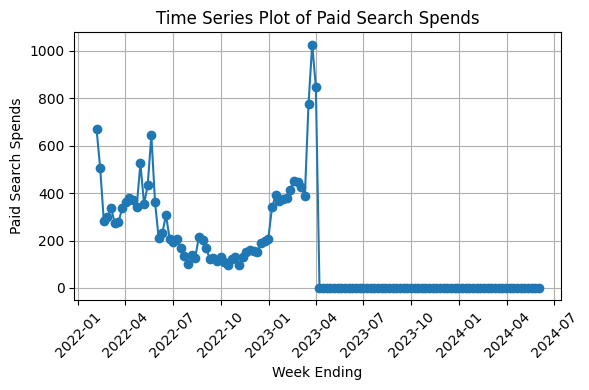

In [50]:
# List of variables to plot
variables =df.columns[:-1]

# Create time series plots for each variable
for variable in variables:
    plt.figure(figsize=(6, 4))
    plt.plot(df['Week_Ending'], df[variable], marker='o')
    plt.title(f'Time Series Plot of {variable}')
    plt.xlabel('Week Ending')
    plt.ylabel(variable)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [51]:
# Exploratory Data Analysis (EDA)
# Summary statistics(last column contains weeks,hence not included)
df.iloc[:,:-1].describe()

,Sales,Discount1,Discount2,Holiday Dummy,Total SKU,Gasoline Price,Average Price,Email Clicks,Email Spends,Organic Search Impressions,Modular Video Impressions,Modular Video Spends,Paid Social Impressions,Paid Social Spends,Paid Search Impressions,Paid Search Spends
count,1.220000e+02,122.000000,122.000000,122.000000,1.220000e+02,122.000000,122.000000,1.220000e+02,122.000000,1.220000e+02,1.220000e+02,1.220000e+02,1.220000e+02,1.220000e+02,122.000000,122.000000
mean,4.716817e+07,0.045865,0.048454,0.016393,2.733039e+07,1141.034570,18.232506,4.383132e+05,37734.537898,1.973459e+06,1.342260e+07,9.433634e+05,2.028083e+08,2.792205e+06,1522.872951,150.938152
std,4.904374e+06,0.020532,0.066932,0.127507,1.986457e+06,128.779133,0.235631,1.746694e+05,15037.350764,3.844069e+05,6.033649e+06,4.240552e+05,7.892941e+07,1.086677e+06,2051.580642,203.340528
min,3.158512e+07,0.013620,0.002513,0.000000,2.377588e+07,966.010500,17.716258,1.655045e+05,14248.340587,8.734215e+05,1.924108e+06,1.352296e+05,6.940367e+07,9.555292e+05,0.000000,0.000000
25%,4.444759e+07,0.032922,0.007754,0.000000,2.590976e+07,1051.745625,18.051530,3.169416e+05,27285.615915,1.708429e+06,9.235256e+06,6.490696e+05,1.399515e+08,1.926810e+06,0.000000,0.000000
50%,4.692418e+07,0.041603,0.017871,0.000000,2.687210e+07,1114.687000,18.210772,4.256770e+05,36646.682574,1.943811e+06,1.191968e+07,8.377356e+05,1.858422e+08,2.558620e+06,490.000000,48.565899
75%,5.047277e+07,0.057146,0.057452,0.000000,2.925184e+07,1186.125500,18.414389,5.104199e+05,43942.226474,2.220258e+06,1.749417e+07,1.229520e+06,2.727134e+08,3.754638e+06,2648.625000,262.516030
max,5.839206e+07,0.178189,0.342303,1.000000,3.109905e+07,1505.497000,18.709714,1.254225e+06,107976.671165,3.125528e+06,3.799969e+07,2.670683e+06,3.689925e+08,5.080180e+06,10363.500000,1027.168769


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Sales                       122 non-null    float64       
 1   Discount1                   122 non-null    float64       
 2   Discount2                   122 non-null    float64       
 3   Holiday Dummy               122 non-null    int64         
 4   Total SKU                   122 non-null    float64       
 5   Gasoline Price              122 non-null    float64       
 6   Average Price               122 non-null    float64       
 7   Email Clicks                122 non-null    float64       
 8   Email Spends                122 non-null    float64       
 9   Organic Search Impressions  122 non-null    float64       
 10  Modular Video Impressions   122 non-null    float64       
 11  Modular Video Spends        122 non-null    float64       

In [53]:
# Check for missing values
df.isnull().sum()

Sales                         0
Discount1                     0
Discount2                     0
Holiday Dummy                 0
Total SKU                     0
Gasoline Price                0
Average Price                 0
Email Clicks                  0
Email Spends                  0
Organic Search Impressions    0
Modular Video Impressions     0
Modular Video Spends          0
Paid Social Impressions       0
Paid Social Spends            0
Paid Search Impressions       0
Paid Search Spends            0
Week_Ending                   0
dtype: int64

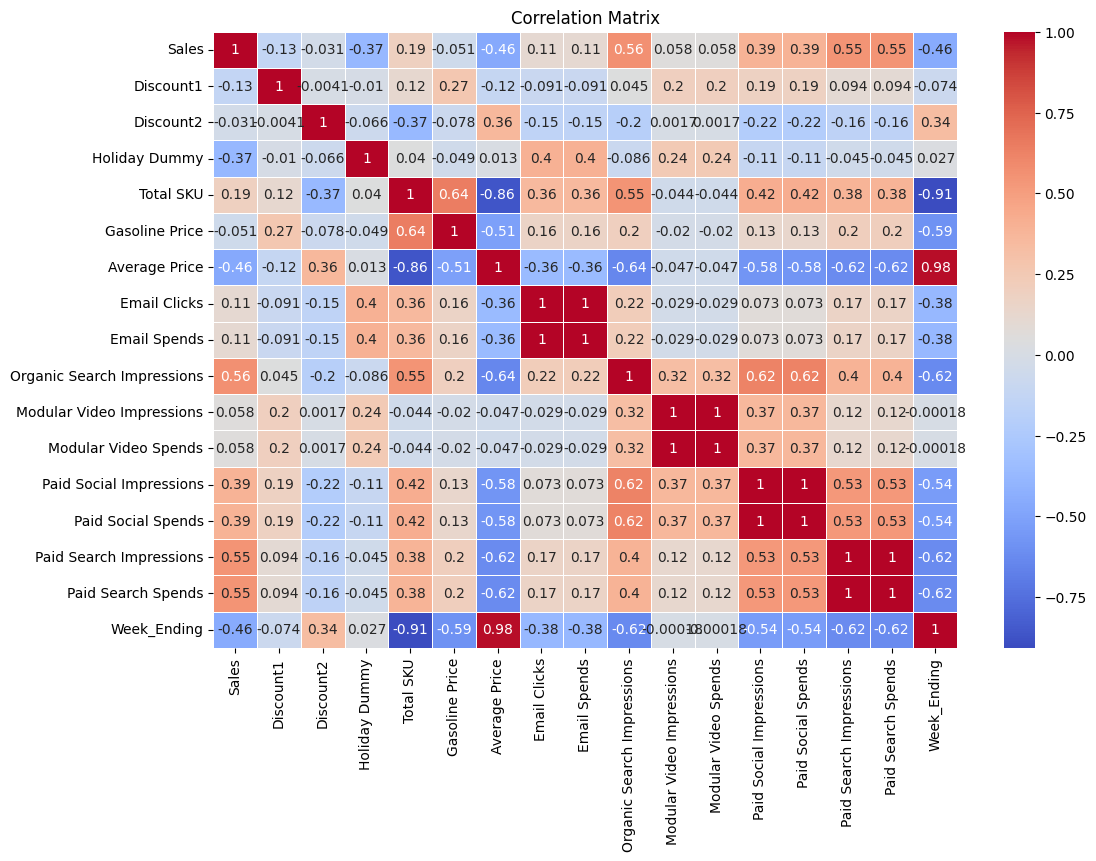

In [54]:
# Correlation matrix
correlation_matrix = df.corr()
# Plotting the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [55]:
# Correlation between sales and sales drivers
df.corr()['Sales'].sort_values(ascending=False)

Sales                         1.000000
Organic Search Impressions    0.563395
Paid Search Spends            0.546764
Paid Search Impressions       0.546764
Paid Social Spends            0.392407
Paid Social Impressions       0.392407
Total SKU                     0.189031
Email Spends                  0.110840
Email Clicks                  0.110840
Modular Video Spends          0.058470
Modular Video Impressions     0.058470
Discount2                    -0.031489
Gasoline Price               -0.050567
Discount1                    -0.131008
Holiday Dummy                -0.374159
Week_Ending                  -0.457652
Average Price                -0.464362
Name: Sales, dtype: float64

In [56]:
df['week index']=df['Week_Ending'].dt.isocalendar().week
df["Seasonality"] = df.groupby(['week index'])["Sales"].transform('mean')/df['Sales'].mean()

In [57]:
def apl_transformation(series, adstock_rate=0.5, power=0.5):
    result = []
    for i in range(len(series)):
        if i == 0:
            result.append(series[i] ** power)
        else:
            result.append((series[i] + adstock_rate * result[i - 1]) ** power)
    return result

# Define specific adstock_rate and power values for each tactic from domain knowledge
tactic_params = {
    'Paid Search Impressions': {'adstock_rate': 0.5, 'power': 0.6},
    'Paid Social Impressions': {'adstock_rate': 0.7, 'power': 0.6},
    'Modular Video Impressions': {'adstock_rate': 0.7, 'power': 0.8},
    'Email Clicks': {'adstock_rate': 0.4, 'power': 0.5},
    'Organic Search Impressions': {'adstock_rate': 0.5, 'power': 0.8}
}

# Apply APL transformation using the specific parameters
for column, params in tactic_params.items():
    df[column] = apl_transformation(df[column], adstock_rate=params['adstock_rate'], power=params['power'])

In [58]:
# Create 1-week and 2-week lagged versions of 'Discount1' and 'Discount2'
df['Discount1_lag1'] = df['Discount1'].shift(1)
df['Discount1_lag2'] = df['Discount1'].shift(2)
df['Discount2_lag1'] = df['Discount2'].shift(1)
df['Discount2_lag2'] = df['Discount2'].shift(2)

# Fill NaN values with the last valid observation
df.loc[0, 'Discount1_lag1'] = df.loc[1, 'Discount1_lag1']
df.loc[0, 'Discount1_lag2'] = df.loc[1, 'Discount1_lag2']
df.loc[0, 'Discount2_lag1'] = df.loc[1, 'Discount2_lag1']    
df.loc[0, 'Discount2_lag2'] = df.loc[1, 'Discount2_lag2']

# Compute the correlation with 'Sales'
correlation_matrix = df[['Sales','Discount1','Discount2','Discount1_lag1', 'Discount1_lag2', 'Discount2_lag1', 'Discount2_lag2']].corr()['Sales']

# Print the correlation matrix
print("Correlation matrix:")
print(correlation_matrix)

df.drop(columns=['Discount1'], inplace=True)

Correlation matrix:
Sales             1.000000
Discount1        -0.131008
Discount2        -0.031489
Discount1_lag1   -0.104454
Discount1_lag2   -0.023320
Discount2_lag1   -0.124524
Discount2_lag2   -0.224424
Name: Sales, dtype: float64


In [59]:
df['Gasoline Price_3'] = df['Gasoline Price'].rolling(window=3).mean()
df.loc[0:1, 'Gasoline Price_3'] = df.loc[2, 'Gasoline Price_3']
df['Gasoline Price_4'] = df['Gasoline Price'].rolling(window=4).mean()
df.loc[0:2, 'Gasoline Price_4'] = df.loc[3, 'Gasoline Price_4']
# Compute the correlation with 'Sales'
print(df[['Sales','Gasoline Price','Gasoline Price_3','Gasoline Price_4']].corr()['Sales'])

#Using 4 week moving average for gasoline price
df['Gasoline Price']=df['Gasoline Price_4']


Sales               1.000000
Gasoline Price     -0.050567
Gasoline Price_3   -0.078479
Gasoline Price_4   -0.087753
Name: Sales, dtype: float64


In [60]:
# Modeling Approach
# Define the dependent and independent variables
X = df[['Average Price', 'Total SKU','Paid Search Impressions', 'Paid Social Impressions', 'Modular Video Impressions', 'Email Clicks', 'Organic Search Impressions', 'Gasoline Price', 'Discount2', 'Seasonality']]
y = df['Sales']
X = sm.add_constant(X)

In [61]:
# Fit the linear regression model
model = sm.OLS(y, X).fit()
model_summary = model.summary()
print(model_summary)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     231.2
Date:                Wed, 11 Jun 2025   Prob (F-statistic):           1.89e-69
Time:                        01:29:05   Log-Likelihood:                -1864.0
No. Observations:                 122   AIC:                             3750.
Df Residuals:                     111   BIC:                             3781.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

In [62]:
# Calculate R-squared and Adjusted R-squared
r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
r_squared, adj_r_squared

(0.9541895035828638, 0.9500624318335723)

In [63]:
# Calculate MAPE
y_pred = model.predict(X)
mape = mean_absolute_percentage_error(y, y_pred)
mape

0.016485366968017594

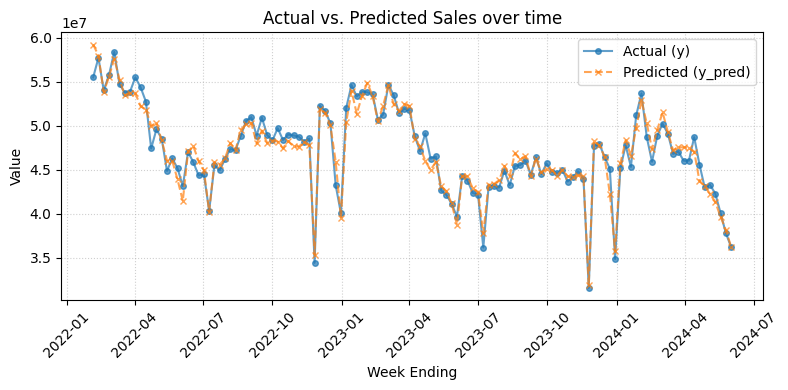

In [64]:
plt.figure(figsize=(8, 4))
# Plot actual values
plt.plot(df["Week_Ending"], y, label='Actual (y)', marker='o', linestyle='-', markersize=4, alpha=0.7)
# Plot predicted values
plt.plot(df["Week_Ending"], y_pred, label='Predicted (y_pred)', marker='x', linestyle='--', markersize=4, alpha=0.7)
plt.xlabel("Week Ending")
plt.ylabel("Value")
plt.title("Actual vs. Predicted Sales over time")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Improve x-axis date formatting
plt.xticks(rotation=45)
plt.tight_layout() # Adjusts plot to prevent labels from overlapping
plt.show()